# Notebook for visualizing GRID scheme metrics for both stric and loose bucketing methods 

This includes making plots in order to show how these metrics evolve over thresholds and dataset sizes. 

# Setup

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from functions_grid import *
from functions_bucket_stats import *

In [22]:
MEASURE = "dtw" #Either dtw or frechet
BUCKETING_METHOD = "loose" #Either original or loose
CITY = "porto" #Either rome or porto

if MEASURE == "dtw":
    THRESHOLDS = [0.1, 0.2, 0.3, 0.4, 0.5] #DTW
    THRESHOLD_LOWEST = 0.1
    SIZES = [500] #500 - 1500 for dtw, 50-150 for frechet


#Frechet
elif MEASURE == "frechet":
    THRESHOLDS = [0.002, 0.004, 0.006, 0.008, 0.01] #Frechet
    THRESHOLD_LOWEST = 0.002
    SIZES = [50, 100, 150] #500 - 1500 for dtw, 50-150 for frechet

    
#Fetch the correct file

files = []

for size in SIZES:
    files.append(f"../results_hashed/bucket_evaluation/{BUCKETING_METHOD}/{CITY}/grid/{CITY}_{MEASURE}_grid_{size}_{BUCKETING_METHOD}.csv")



print("Chosen configuration:")
print(f"Scheme: GRID")
print(f"City: {CITY}")
print(f"Measure: {MEASURE}")
print(f"Bucketing method: {BUCKETING_METHOD}")
print(f"Size: {SIZES}")
print(f"Grid files:")
for file in files:
    print(f"\t{file}\n")
    
print(f"Thresholds: {THRESHOLDS}")
print(f"Threshold lowest: {THRESHOLD_LOWEST}")

#load into pandas
dfs = []
for file in files:
    df = pd.read_csv(file)
    dfs.append(df)

#All data should have the same values for resolution and layers. 

Chosen configuration:
Scheme: GRID
City: rome
Measure: dtw
Bucketing method: loose
Size: [1500]
Grid files:
	../results_hashed/bucket_evaluation/loose/rome/grid/rome_dtw_grid_1500_loose.csv

Thresholds: [0.1, 0.2, 0.3, 0.4, 0.5]
Threshold lowest: 0.1


# Precision, Recall and F1 Metrics

In [23]:
# #Main paramaters

# drop_columns = ['Avg Number of buckets',
#        'Avg Bucket size', 'Avg Buckets with >1 Trajectory',
#        'Avg Largest Bucket Size', 'Avg Correlation Coefficient']


# #Filter each df
# for i in range(len(dfs)):
#     dfs[i] = dfs[i].drop(columns=drop_columns)
#     # dfs[i] = dfs[i][dfs[i]['Threshold'].isin([0.1])]
#     # dfs[i] = dfs[i][dfs[i]['Resolution'] <= 0.1]



# thresholds = [0.1]
# if BUCKETING_METHOD == "original":
#     bucketing_method_name= "strict"
# else:
#     bucketing_method_name= "loose"


# plot_mean_values_grid_sizes(dfs, CITY, "grid", MEASURE, bucketing_method_name, thresholds, SIZES, 0.2)

# Layers effect on evaluations

In [24]:
# if BUCKETING_METHOD == "original":
#     bucketing_method_name= "strict"
# else:
#     bucketing_method_name= "loose"

# thresholds = [0.1]

# for i in range(len(dfs)):
#     dfs[i] = dfs[i][dfs[i]['Resolution'] <= 0.1]


# # plot_layers_vs_resolution2(dfs, SIZES, CITY, "grid", MEASURE, bucketing_method_name, 0.2)
# # plot_layers_vs_resolution2_two_rows(dfs, SIZES, CITY, "grid", MEASURE, bucketing_method_name, 0.2)
# plot_layers_vs_resolution2_1_2_layout(dfs, SIZES, CITY, "grid", MEASURE, bucketing_method_name, 0.01)

# Bucket evaluation

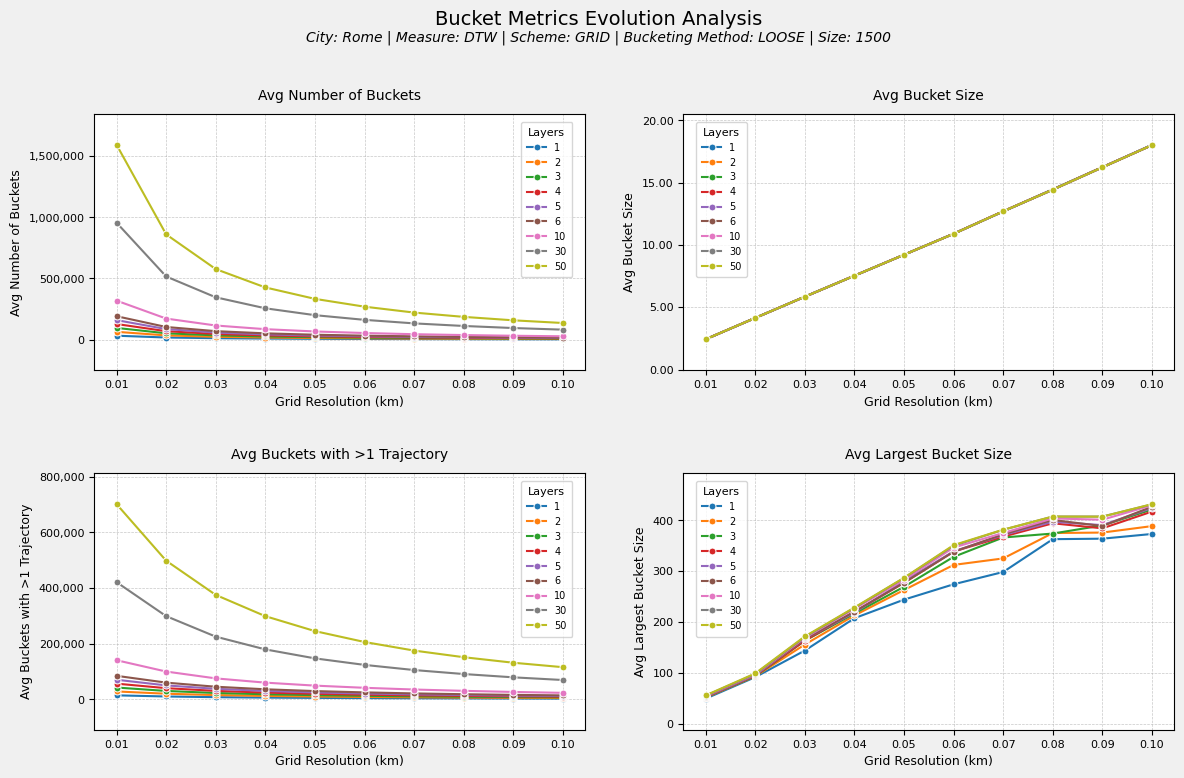

In [25]:
# Remove the drop_columns part
drop_columns = ['Avg Number of buckets',
       'Avg Bucket size', 'Avg Buckets with >1 Trajectory',
       'Avg Largest Bucket Size', 'Avg Correlation Coefficient']

# Just filter by Threshold
for i in range(len(dfs)):
    dfs[i] = dfs[i][dfs[i]['Threshold'].isin([0.1])]
    dfs[i] = dfs[i][dfs[i]['Resolution'] <=0.1]
    
    
if BUCKETING_METHOD == "original":
    bucketing_method_name= "strict"
else:
    bucketing_method_name= "loose"

plot_bucket_metrics_evolution_combined(dfs, SIZES, CITY, MEASURE, "Grid", bucketing_method_name, SIZES[0], major_xticks=0.01, minor_xticks=0.05)